## HDB Residential Buildings

Description: To be updated

Data Source: [Singapore Open Data Portal](https://data.gov.sg/)

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import requests
import time
import os
import zipfile
from bs4 import BeautifulSoup as bs
from IPython.display import SVG

### Data Collection

In [2]:
data_fold = './hdb-properties'
if not os.path.isdir(data_fold):
    os.mkdir(data_fold)

In [3]:
data_file = os.path.join(data_fold,'hdb-property-info.csv')
if os.path.exists(data_file):
    hdb = pd.read_csv(data_file, encoding='utf-8', index_col='_id')
else:
    hdb = pd.DataFrame()
    req = requests.get('https://data.gov.sg/api/action/datastore_search',params={'resource_id':'482bfa14-2977-4035-9c61-c85f871daf4e','limit':12626})
    if req.status_code == 200:
        while req.status_code == 200 and len(req.json()['result']['records']) > 0:
            hdb = pd.concat((hdb, pd.DataFrame.from_records(req.json()['result']['records'], index='_id')), axis=0)
            time.sleep(.05)
            req = requests.get('https://data.gov.sg/{}'.format(req.json()['result']['_links']['next']))
    del req
    hdb.sort_index(inplace=True)
    hdb.to_csv(data_file,encoding='utf-8')
hdb.head(5)

,year_completed,multigen_sold,bldg_contract_town,multistorey_carpark,street,total_dwelling_units,blk_no,exec_sold,max_floor_lvl,residential,...,3room_sold,commercial,4room_sold,miscellaneous,studio_apartment_sold,2room_rental,2room_sold,1room_rental,3room_rental,market_hawker
_id,,,,,,,,,,,,,,,,,,,,,
1,1970,0,KWN,N,BEACH RD,142,1,0,16,Y,...,138,Y,1,N,0,0,1,0,0,N
2,1975,0,BD,N,BEDOK STH AVE 1,206,1,0,14,Y,...,204,N,0,Y,0,0,0,0,0,N
3,2010,0,CT,N,CANTONMENT RD,0,1,0,2,N,...,0,Y,0,N,0,0,0,0,0,N
4,1982,0,BD,N,CHAI CHEE RD,102,1,0,15,Y,...,0,N,10,N,0,0,0,0,0,N
5,1975,0,PRC,N,CHANGI VILLAGE RD,55,1,0,4,Y,...,54,Y,0,N,0,0,0,0,0,N


In [4]:
hdb.shape

(12626, 24)

In [5]:
hdb['address'] = hdb['blk_no'].str.cat(hdb['street'],' ')

In [6]:
hdb.head(5)

,year_completed,multigen_sold,bldg_contract_town,multistorey_carpark,street,total_dwelling_units,blk_no,exec_sold,max_floor_lvl,residential,...,commercial,4room_sold,miscellaneous,studio_apartment_sold,2room_rental,2room_sold,1room_rental,3room_rental,market_hawker,address
_id,,,,,,,,,,,,,,,,,,,,,
1,1970,0,KWN,N,BEACH RD,142,1,0,16,Y,...,Y,1,N,0,0,1,0,0,N,1 BEACH RD
2,1975,0,BD,N,BEDOK STH AVE 1,206,1,0,14,Y,...,N,0,Y,0,0,0,0,0,N,1 BEDOK STH AVE 1
3,2010,0,CT,N,CANTONMENT RD,0,1,0,2,N,...,Y,0,N,0,0,0,0,0,N,1 CANTONMENT RD
4,1982,0,BD,N,CHAI CHEE RD,102,1,0,15,Y,...,N,10,N,0,0,0,0,0,N,1 CHAI CHEE RD
5,1975,0,PRC,N,CHANGI VILLAGE RD,55,1,0,4,Y,...,Y,0,N,0,0,0,0,0,N,1 CHANGI VILLAGE RD


In [7]:
data_file = os.path.join(data_fold,'hdb-property-coordinates.csv')
if os.path.exists(data_file):
    hdb_g = pd.read_csv(data_file, encoding='utf-8', index_col=0)
else:
    hdb_g = pd.DataFrame()
for address in hdb['address']:
    if 'search' not in hdb_g or hdb_g.loc[hdb_g['search'].eq(address),:].index.size == 0:
        time.sleep(.005)
        req = requests.get(
            url='https://developers.onemap.sg/commonapi/search', 
            params={
                'token':os. environ['onemap'],
                'searchVal': address,
                'returnGeom': 'Y',
                'getAddrDetails': 'Y'
            })
        if req.status_code == 200:
            add_df = pd.DataFrame.from_records(req.json()['results'])
            if add_df.index.size > 0:
                add_df.rename(columns=dict(zip(add_df.columns, add_df.columns.str.lower())), inplace=True)
                add_df['search'] = address
                hdb_g = pd.concat((hdb_g,add_df),axis=0)
del address, add_df, req
hdb_g.to_csv(data_file, encoding='utf-8')
hdb_g.head(5)

,searchval,blk_no,road_name,building,address,postal,x,y,latitude,longitude,longtitude,search
0,RAFFLES HOTEL,1,BEACH ROAD,RAFFLES HOTEL,1 BEACH ROAD RAFFLES HOTEL SINGAPORE 189673,189673,30309.267249,30830.819599,1.295097,103.854068,103.854068,1 BEACH RD
1,RAFFLES HOTEL SINGAPORE,1,BEACH ROAD,RAFFLES HOTEL SINGAPORE,1 BEACH ROAD RAFFLES HOTEL SINGAPORE SINGAPORE...,189673,30353.688694,30798.089103,1.294801,103.854467,103.854467,1 BEACH RD
2,BEACH ROAD GARDENS,1,BEACH ROAD,BEACH ROAD GARDENS,1 BEACH ROAD BEACH ROAD GARDENS SINGAPORE 190001,190001,31467.832743,31778.893997,1.303671,103.864479,103.864479,1 BEACH RD
3,MY FIRST SKOOL,1,BEDOK SOUTH AVENUE 1,MY FIRST SKOOL,1 BEDOK SOUTH AVENUE 1 MY FIRST SKOOL SINGAPOR...,460001,39173.812898,33678.855985,1.320852,103.933721,103.933721,1 BEDOK STH AVE 1
4,1 BEDOK SOUTH AVENUE 1 SINGAPORE 460001,1,BEDOK SOUTH AVENUE 1,NIL,1 BEDOK SOUTH AVENUE 1 SINGAPORE 460001,460001,39173.812353,33678.855652,1.320852,103.933721,103.933721,1 BEDOK STH AVE 1


In [8]:
hdb_g = hdb_g.drop(columns=['searchval','address','longtitude'])
hdb_g.head(5)

,blk_no,road_name,building,postal,x,y,latitude,longitude,search
0,1,BEACH ROAD,RAFFLES HOTEL,189673,30309.267249,30830.819599,1.295097,103.854068,1 BEACH RD
1,1,BEACH ROAD,RAFFLES HOTEL SINGAPORE,189673,30353.688694,30798.089103,1.294801,103.854467,1 BEACH RD
2,1,BEACH ROAD,BEACH ROAD GARDENS,190001,31467.832743,31778.893997,1.303671,103.864479,1 BEACH RD
3,1,BEDOK SOUTH AVENUE 1,MY FIRST SKOOL,460001,39173.812898,33678.855985,1.320852,103.933721,1 BEDOK STH AVE 1
4,1,BEDOK SOUTH AVENUE 1,NIL,460001,39173.812353,33678.855652,1.320852,103.933721,1 BEDOK STH AVE 1


In [9]:
data_file = os.path.join(data_fold,'master_plan_subzone.zip')
if not os.path.exists(data_file):
    req = requests.get(url='https://data.gov.sg/dataset/c754450d-ecbd-4b7d-8dc1-c07ee842c6d1/download', stream=True)
    if req.status_code == 200:
        with open(data_file, 'wb') as file:
            for chunk in req.iter_content(chunk_size=128):
                file.write(chunk)
    del req, file, chunk
zipfile.ZipFile(data_file).infolist()

[<ZipInfo filename='metadata-master-plan-2019-subzone-boundary-no-sea.txt' filemode='?rw-------' file_size=2008>,
 <ZipInfo filename='master-plan-2019-subzone-boundary-no-sea-kml.kml' filemode='?rw-------' file_size=2748388>,
 <ZipInfo filename='master-plan-2019-subzone-boundary-no-sea-geojson.geojson' filemode='?rw-------' file_size=3106065>]

In [10]:
with zipfile.ZipFile(data_file) as zipf:
    with zipf.open('master-plan-2019-subzone-boundary-no-sea-geojson.geojson') as mpb:
        sgmap = gpd.read_file(mpb)
del zipf, mpb
sgmap.head(5)

,Name,Description,geometry
0,kml_1,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.88025 1.28386 0.00000, 103.880..."
1,kml_2,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.83764 1.29560 0.00000, 103.837..."
2,kml_3,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.83410 1.29248 0.00000, 103.834..."
3,kml_4,<center><table><tr><th colspan='2' align='cent...,"MULTIPOLYGON Z (((103.71253 1.29163 0.00000, 1..."
4,kml_5,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.84718 1.29700 0.00000, 103.847..."


In [11]:
def process_table(html):
    soup = bs(html, 'html.parser')
    keys = soup('th', attrs={'colspan':''})
    keys = [key.get_text() for key in keys]
    vals = soup('td')
    vals = [val.get_text() for val in vals]
    return dict(zip(keys,vals))
sgmap = sgmap.merge(right=pd.DataFrame.from_dict(sgmap['Description'].apply(process_table).tolist()), left_index=True, right_index=True, how='left')
sgmap.head(5)

,Name,Description,geometry,SUBZONE_NO,SUBZONE_N,SUBZONE_C,CA_IND,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D
0,kml_1,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.88025 1.28386 0.00000, 103.880...",1,MARINA EAST,MESZ01,Y,MARINA EAST,ME,CENTRAL REGION,CR,4FB7E5B1B9455DE0,20191223152313
1,kml_2,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.83764 1.29560 0.00000, 103.837...",5,INSTITUTION HILL,RVSZ05,Y,RIVER VALLEY,RV,CENTRAL REGION,CR,C3C22D1EE31757BD,20191223152313
2,kml_3,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.83410 1.29248 0.00000, 103.834...",1,ROBERTSON QUAY,SRSZ01,Y,SINGAPORE RIVER,SR,CENTRAL REGION,CR,87306ABAF4B67E2E,20191223152313
3,kml_4,<center><table><tr><th colspan='2' align='cent...,"MULTIPOLYGON Z (((103.71253 1.29163 0.00000, 1...",1,JURONG ISLAND AND BUKOM,WISZ01,N,WESTERN ISLANDS,WI,WEST REGION,WR,C87E378D3456FC35,20191223152313
4,kml_5,<center><table><tr><th colspan='2' align='cent...,"POLYGON Z ((103.84718 1.29700 0.00000, 103.847...",2,FORT CANNING,MUSZ02,Y,MUSEUM,MU,CENTRAL REGION,CR,8E8F2616FFA9E019,20191223152313


In [12]:
sgmap.drop(columns=['Description'], inplace=True)
sgmap.rename(columns=dict(zip(sgmap.columns,sgmap.columns.str.lower())), inplace=True)
sgmap.set_index(keys=['name'], inplace=True)
sgmap.head(5)

,geometry,subzone_no,subzone_n,subzone_c,ca_ind,pln_area_n,pln_area_c,region_n,region_c,inc_crc,fmel_upd_d
name,,,,,,,,,,,
kml_1,"POLYGON Z ((103.88025 1.28386 0.00000, 103.880...",1,MARINA EAST,MESZ01,Y,MARINA EAST,ME,CENTRAL REGION,CR,4FB7E5B1B9455DE0,20191223152313
kml_2,"POLYGON Z ((103.83764 1.29560 0.00000, 103.837...",5,INSTITUTION HILL,RVSZ05,Y,RIVER VALLEY,RV,CENTRAL REGION,CR,C3C22D1EE31757BD,20191223152313
kml_3,"POLYGON Z ((103.83410 1.29248 0.00000, 103.834...",1,ROBERTSON QUAY,SRSZ01,Y,SINGAPORE RIVER,SR,CENTRAL REGION,CR,87306ABAF4B67E2E,20191223152313
kml_4,"MULTIPOLYGON Z (((103.71253 1.29163 0.00000, 1...",1,JURONG ISLAND AND BUKOM,WISZ01,N,WESTERN ISLANDS,WI,WEST REGION,WR,C87E378D3456FC35,20191223152313
kml_5,"POLYGON Z ((103.84718 1.29700 0.00000, 103.847...",2,FORT CANNING,MUSZ02,Y,MUSEUM,MU,CENTRAL REGION,CR,8E8F2616FFA9E019,20191223152313


### Data Cleaning

Most of the data cleaning here is to figure out which match from a large list of duplicate matches for a significant number (~$1/6$) of addresses to keep.
The order of search is as follows.
First, hotels are all thrown out.
Next, exact matches on building number and street name are kept.
Finally, among remaining multiple matches I match on an interesting fact about postal codes in Singapore: for public housing projects, the last three digits of the postal code is the building number of that building.
This serves my purpose well here since the dataset for which I am trying to geocode addresses are the buildings constructed by the public housing authority.
These three rules in order exactly identify one valid address for each address with multiple geocoding matches.

In [13]:
hdb_g_dup = hdb_g.loc[hdb_g.duplicated(subset=['search'],keep=False),:].copy(deep=True)
hdb_g_dup[['search_blk','search_rd']] = hdb_g_dup['search'].str.split(pat=' ', n=1, expand=True)
hdb_g_dup = hdb_g_dup.loc[~hdb_g_dup['building'].str.contains('HOTEL'),:]
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bST\.', 'SAINT', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bRD\b', 'ROAD', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bDR\b', 'DRIVE', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bST\b', 'STREET', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bAVE\b', 'AVENUE', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bJLN\b', 'JALAN', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bLOR\b', 'LORONG', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bCRES\b', 'CRESCENT', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bGDNS\b', 'GARDENS', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bHTS\b', 'HEIGHTS', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bPL\b', 'PLACE', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bTER\b', 'TERRACE', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bKG\b', 'KAMPONG', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bCL\b', 'CLOSE', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bNTH\b', 'NORTH', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bSTH\b', 'SOUTH', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bCTRL\b', 'CENTRAL', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bUPP\b', 'UPPER', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bPK\b', 'PARK', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bBT\b', 'BUKIT', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bTG\b', 'TANJONG', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bMKT\b', 'MARKET', regex=True)
hdb_g_dup['search_rd'] = hdb_g_dup['search_rd'].str.replace(r'\bC\'WEALTH\b', 'COMMONWEALTH', regex=True)
hdb_g_dup['match'] = hdb_g_dup['road_name'].eq(hdb_g_dup['search_rd'])&hdb_g_dup['blk_no'].eq(hdb_g_dup['search_blk'])
hdb_g_dup = hdb_g_dup.loc[hdb_g_dup['match'],:]
hdb_g_dup = hdb_g_dup.drop_duplicates(subset=['search','postal'], keep='first')
hdb_g_dup = hdb_g_dup.drop(columns=['search_blk','search_rd','match'])
hdb_g_dup['match_count'] = hdb_g_dup.groupby(by=['search'])['search'].transform('count')
hdb_g_dup['match_postal'] = hdb_g_dup['blk_no'].astype('str').str.replace(r'[a-zA-Z]$', '', regex=True).eq(hdb_g_dup['postal'].str[-3:].str.replace(r'^0+', '', regex=True))
hdb_g_dup = hdb_g_dup.loc[hdb_g_dup['match_count'].eq(1)|(hdb_g_dup['match_count'].ge(2)&hdb_g_dup['match_postal']),:]
hdb_g_dup = hdb_g_dup.drop(columns=['match_count','match_postal'])
print('number of duplicates:', hdb_g_dup['search'].duplicated(keep=False).sum())
# hdb_g_dup.loc[hdb_g_dup.duplicated(subset=['search'], keep=False),:].head(10)
# hdb_g_dup.groupby(by=['search'])['match'].sum().sort_values()
# hdb_g_dup[['road_name','search_rd']].drop_duplicates().query('road_name!=search_rd')

number of duplicates: 0


In [14]:
print('addresses remaining:', hdb_g_dup['search'].size)

addresses remaining: 2125


In [15]:
print('addresses to match:', hdb_g.loc[hdb_g.duplicated(subset=['search'],keep=False),:].drop_duplicates(subset=['search'],keep='first').index.size)

addresses to match: 2125


In [16]:
hdb_g_dup.head(5)

,blk_no,road_name,building,postal,x,y,latitude,longitude,search
2,1,BEACH ROAD,BEACH ROAD GARDENS,190001,31467.832743,31778.893997,1.303671,103.864479,1 BEACH RD
3,1,BEDOK SOUTH AVENUE 1,MY FIRST SKOOL,460001,39173.812898,33678.855985,1.320852,103.933721,1 BEDOK STH AVE 1
5,1,CANTONMENT ROAD,PINNACLE @ DUXTON,080001,28901.518219,28662.514016,1.275488,103.841419,1 CANTONMENT RD
9,1,CHANGI VILLAGE ROAD,NIL,500001,45192.299295,41164.501199,1.388547,103.987805,1 CHANGI VILLAGE RD
13,1,DOVER ROAD,DOVER COURT,130001,22430.399338,31652.252935,1.302526,103.783273,1 DOVER RD


After I merge the geographic coordinates to main properties data set, there are a couple of addresses left that were not geocoded or had some missing elements from the fetched addresses.
I fill them out manually here.
Given the number of remaining matches I manually input the geographic coordinates by manual Google map search (OpenStreetMap fails to find these addresses as well).
If it ever gets worse than this then one would need to look into using the Google Maps API for Geocoding (not a free service).

In [17]:
hdb_g_dup = pd.concat((hdb_g.loc[~hdb_g.duplicated(subset=['search'],keep=False),:].copy(deep=True),hdb_g_dup),axis=0)
hdb_g_dup = hdb_g_dup.drop(columns=['blk_no','road_name','building'])
hdb.merge(right=hdb_g_dup, left_on=['address'], right_on=['search'], how='outer').sort_values(by=['postal']).tail(6)

,year_completed,multigen_sold,bldg_contract_town,multistorey_carpark,street,total_dwelling_units,blk_no,exec_sold,max_floor_lvl,residential,...,1room_rental,3room_rental,market_hawker,address,postal,x,y,latitude,longitude,search
11866,2016,0,PG,N,PUNGGOL CTRL,0,85,0,3,N,...,0,0,N,85 PUNGGOL CTRL,828726,35798.962134,43277.085512,1.407656,103.903399,85 PUNGGOL CTRL
3083,1989,0,CCK,N,CHOA CHU KANG CTRL,16,216,0,4,Y,...,0,0,N,216 CHOA CHU KANG CTRL,NIL,18402.364547,40559.983762,1.383083,103.747077,216 CHOA CHU KANG CTRL
3062,1989,0,CCK,N,CHOA CHU KANG CTRL,90,215,0,11,Y,...,0,0,N,215 CHOA CHU KANG CTRL,NIL,18402.364547,40559.983762,1.383083,103.747077,215 CHOA CHU KANG CTRL
1519,1995,0,SGN,Y,SERANGOON NTH AVE 2,0,141A,0,5,N,...,0,0,N,141A SERANGOON NTH AVE 2,NaN,NaN,NaN,NaN,NaN,NaN
6105,2017,0,WL,N,WOODLANDS ST 12,0,4,0,5,N,...,0,0,N,4 WOODLANDS ST 12,NaN,NaN,NaN,NaN,NaN,NaN
7860,1973,0,CT,N,BANDA ST,430,5,0,21,Y,...,430,0,N,5 BANDA ST,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
hdb = hdb.merge(right=hdb_g_dup, left_on=['address'], right_on=['search'], how='outer')
hdb = hdb.drop(columns=['search'])
hdb.loc[hdb['address'].eq('216 CHOA CHU KANG CTRL'),'postal'] = '680216'
hdb.loc[hdb['address'].eq('215 CHOA CHU KANG CTRL'),'postal'] = '680215'
hdb.loc[hdb['address'].eq('141A SERANGOON NTH AVE 2'),['postal','latitude','longitude']] = ['550141', '1.3686774567530855', '103.87415290329253']
hdb.loc[hdb['address'].eq('4 WOODLANDS ST 12'),['postal','latitude','longitude']] = ['738620', '1.4337033085073017', '103.77982248372486']
hdb.loc[hdb['address'].eq('5 BANDA ST'),['postal','latitude','longitude']] = ['050005', '1.2813847452968326', '103.84336169114782']
hdb.sort_values(by=['postal']).tail(6)

,year_completed,multigen_sold,bldg_contract_town,multistorey_carpark,street,total_dwelling_units,blk_no,exec_sold,max_floor_lvl,residential,...,2room_sold,1room_rental,3room_rental,market_hawker,address,postal,x,y,latitude,longitude
10362,2015,0,PG,N,PUNGGOL DR,110,677D,0,17,Y,...,0,0,0,N,677D PUNGGOL DR,824677,36551.251984,43080.773635,1.40588,103.910159
10389,2016,0,PG,N,PUNGGOL DR,0,679D,0,1,N,...,0,0,0,N,679D PUNGGOL DR,824679,36359.708979,43164.811875,1.406641,103.908438
10469,2017,0,PG,N,EDGEDALE PLAINS,86,684D,0,17,Y,...,0,0,0,N,684D EDGEDALE PLAINS,824684,36989.294966,42834.348389,1.403652,103.914095
2538,2006,0,PG,N,PUNGGOL RD,90,195E,0,16,Y,...,0,0,0,N,195E PUNGGOL RD,825195,36219.468845,42620.499212,1.401718,103.907177
24,2022,0,PG,N,PUNGGOL DR,0,1,0,6,N,...,0,0,0,N,1 PUNGGOL DR,828629,36014.190108,43460.735716,1.409317,103.905333
11866,2016,0,PG,N,PUNGGOL CTRL,0,85,0,3,N,...,0,0,0,N,85 PUNGGOL CTRL,828726,35798.962134,43277.085512,1.407656,103.903399


In [19]:
hdb.loc[hdb['address'].eq('141A SERANGOON NTH AVE 2'),['x','y']] = requests.get(
    url='https://developers.onemap.sg/commonapi/convert/4326to3414', 
    params={
        'token':os. environ['onemap'],
        'latitude': hdb.loc[hdb['address'].eq('141A SERANGOON NTH AVE 2'),'latitude'].iloc[0],
        'longitude': hdb.loc[hdb['address'].eq('141A SERANGOON NTH AVE 2'),'longitude'].iloc[0]
    }).json().values()
hdb.loc[hdb['address'].eq('4 WOODLANDS ST 12'),['x','y']] = requests.get(
    url='https://developers.onemap.sg/commonapi/convert/4326to3414', 
    params={
        'token':os. environ['onemap'],
        'latitude': hdb.loc[hdb['address'].eq('4 WOODLANDS ST 12'),'latitude'].iloc[0],
        'longitude': hdb.loc[hdb['address'].eq('4 WOODLANDS ST 12'),'longitude'].iloc[0]
    }).json().values()
hdb.loc[hdb['address'].eq('5 BANDA ST'),['x','y']] = requests.get(
    url='https://developers.onemap.sg/commonapi/convert/4326to3414', 
    params={
        'token':os. environ['onemap'],
        'latitude': hdb.loc[hdb['address'].eq('5 BANDA ST'),'latitude'].iloc[0],
        'longitude': hdb.loc[hdb['address'].eq('5 BANDA ST'),'longitude'].iloc[0]
    }).json().values()

In [20]:
hdb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12626 entries, 0 to 12625
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year_completed         12626 non-null  int64  
 1   multigen_sold          12626 non-null  int64  
 2   bldg_contract_town     12626 non-null  object 
 3   multistorey_carpark    12626 non-null  object 
 4   street                 12626 non-null  object 
 5   total_dwelling_units   12626 non-null  int64  
 6   blk_no                 12626 non-null  object 
 7   exec_sold              12626 non-null  int64  
 8   max_floor_lvl          12626 non-null  int64  
 9   residential            12626 non-null  object 
 10  1room_sold             12626 non-null  int64  
 11  precinct_pavilion      12626 non-null  object 
 12  other_room_rental      12626 non-null  int64  
 13  5room_sold             12626 non-null  int64  
 14  3room_sold             12626 non-null  int64  
 15  co

In [21]:
cols = hdb.columns[hdb.columns.str.contains(r'_sold|_rental|_lvl|year_', regex=True)]
hdb[cols] = hdb[cols].astype(np.int64)
cols = ['x','y','latitude','longitude']
hdb[cols] = hdb[cols].astype(np.float64)
cols = ['multistorey_carpark','residential','precinct_pavilion','commercial','miscellaneous','market_hawker']
hdb[cols] = hdb[cols].eq('Y').astype(bool)
cols = ['bldg_contract_town','street','blk_no','address','postal']
hdb[cols] = hdb[cols].astype(pd.StringDtype())
del cols
hdb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12626 entries, 0 to 12625
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year_completed         12626 non-null  int64  
 1   multigen_sold          12626 non-null  int64  
 2   bldg_contract_town     12626 non-null  string 
 3   multistorey_carpark    12626 non-null  bool   
 4   street                 12626 non-null  string 
 5   total_dwelling_units   12626 non-null  int64  
 6   blk_no                 12626 non-null  string 
 7   exec_sold              12626 non-null  int64  
 8   max_floor_lvl          12626 non-null  int64  
 9   residential            12626 non-null  bool   
 10  1room_sold             12626 non-null  int64  
 11  precinct_pavilion      12626 non-null  bool   
 12  other_room_rental      12626 non-null  int64  
 13  5room_sold             12626 non-null  int64  
 14  3room_sold             12626 non-null  int64  
 15  co

In [22]:
hdb.head(5)

,year_completed,multigen_sold,bldg_contract_town,multistorey_carpark,street,total_dwelling_units,blk_no,exec_sold,max_floor_lvl,residential,...,2room_sold,1room_rental,3room_rental,market_hawker,address,postal,x,y,latitude,longitude
0,1970,0,KWN,False,BEACH RD,142,1,0,16,True,...,1,0,0,False,1 BEACH RD,190001,31467.832743,31778.893997,1.303671,103.864479
1,1975,0,BD,False,BEDOK STH AVE 1,206,1,0,14,True,...,0,0,0,False,1 BEDOK STH AVE 1,460001,39173.812898,33678.855985,1.320852,103.933721
2,2010,0,CT,False,CANTONMENT RD,0,1,0,2,False,...,0,0,0,False,1 CANTONMENT RD,080001,28901.518219,28662.514016,1.275488,103.841419
3,1982,0,BD,False,CHAI CHEE RD,102,1,0,15,True,...,0,0,0,False,1 CHAI CHEE RD,461001,37949.026473,34465.738569,1.327969,103.922716
4,1975,0,PRC,False,CHANGI VILLAGE RD,55,1,0,4,True,...,0,0,0,False,1 CHANGI VILLAGE RD,500001,45192.299295,41164.501199,1.388547,103.987805


### Exploratory Analysis

In [23]:
ghdb = gpd.GeoDataFrame(data=hdb, geometry=gpd.points_from_xy(x=hdb['longitude'],y=hdb['latitude'],crs='EPSG:4326'))
fig_file = os.path.join(data_fold,'fig_1.svg')
fig, ax = plt.subplots(1,1,figsize=(16,12))
sgmap.boundary.plot(color='black', linewidth=.3, ax=ax)
ghdb[ghdb['residential']].plot(cmap='magma', categories='year_completed', markersize=.3, ax=ax, cax=ax)
sm = mpl.cm.ScalarMappable(cmap='magma', norm=mpl.colors.Normalize(vmin=ghdb['year_completed'].min(), vmax=ghdb['year_completed'].max()))
plt.colorbar(sm, ax=ax, shrink=.6)
t = plt.title('Year of Construction of HDB Residential Buildings')
ax.set_axis_off()
plt.savefig(fig_file, format='svg', bbox_inches='tight', metadata={'Title': t.get_text()})
plt.cla()
plt.close()
SVG(fig_file)

In [24]:
attrmap = sgmap.copy(deep=True)
attrmap = attrmap.merge(right=sgmap.sjoin(df=ghdb, predicate='intersects').groupby(by='name')[['year_completed']].median().astype('int'), left_index=True, right_index=True)
attrmap = attrmap.rename(columns={'year_completed':'median_year_completed'})
attrmap = attrmap.merge(right=sgmap.sjoin(df=ghdb, predicate='intersects').groupby(by='name')[['total_dwelling_units']].sum().astype('int'), left_index=True, right_index=True)
attrmap.head(5)

,geometry,subzone_no,subzone_n,subzone_c,ca_ind,pln_area_n,pln_area_c,region_n,region_c,inc_crc,fmel_upd_d,median_year_completed,total_dwelling_units
name,,,,,,,,,,,,,
kml_15,"POLYGON Z ((103.82868 1.27469 0.00000, 103.828...",15,TELOK BLANGAH RISE,BMSZ15,N,BUKIT MERAH,BM,CENTRAL REGION,CR,E78FC6BA51F16BAF,20191223152313,1976,4361
kml_17,"POLYGON Z ((103.84081 1.27622 0.00000, 103.840...",16,EVERTON PARK,BMSZ16,N,BUKIT MERAH,BM,CENTRAL REGION,CR,CF9CAD50B0D9A528,20191223152313,1980,2739
kml_18,"POLYGON Z ((103.82109 1.27884 0.00000, 103.821...",14,TELOK BLANGAH WAY,BMSZ14,N,BUKIT MERAH,BM,CENTRAL REGION,CR,0F0735F1BDDF53C7,20191223152313,1974,3911
kml_21,"POLYGON Z ((103.82372 1.28189 0.00000, 103.827...",11,KAMPONG TIONG BAHRU,BMSZ11,N,BUKIT MERAH,BM,CENTRAL REGION,CR,CF28DD4E7898CC7B,20191223152313,1981,3685
kml_22,"POLYGON Z ((103.80678 1.28142 0.00000, 103.806...",13,TELOK BLANGAH DRIVE,BMSZ13,N,BUKIT MERAH,BM,CENTRAL REGION,CR,45A0C762C61CD09C,20191223152313,1998,7363


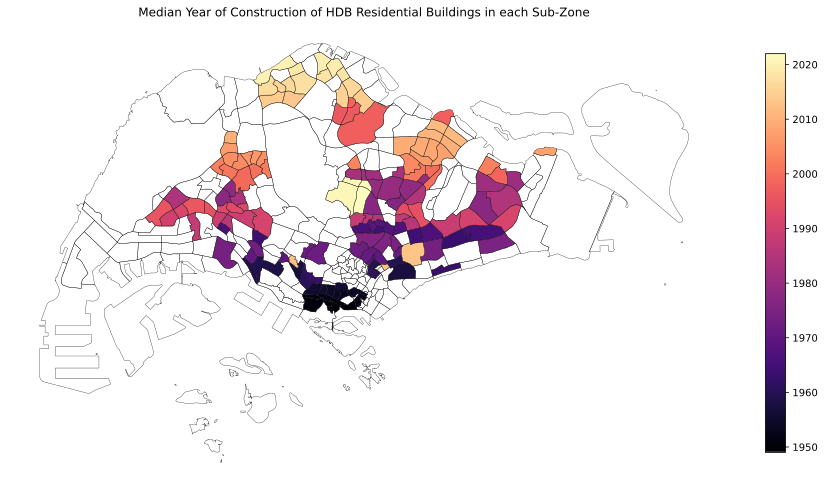

In [25]:
fig_file = os.path.join(data_fold,'fig_2.svg')
fig, ax = plt.subplots(1,1,figsize=(16,12))
sgmap.boundary.plot(color='black', linewidth=.3, ax=ax)
attrmap.plot(cmap='magma', categories='median_year_completed', linewidth=1, ax=ax)
sm = mpl.cm.ScalarMappable(cmap='magma', norm=mpl.colors.Normalize(vmin=attrmap['median_year_completed'].min(), vmax=attrmap['median_year_completed'].max()))
plt.colorbar(sm, ax=ax, shrink=.6)
t = plt.title('Median Year of Construction of HDB Residential Buildings in each Sub-Zone')
ax.set_axis_off()
plt.savefig(fig_file, format='svg', bbox_inches='tight', metadata={'Title': t.get_text()})
plt.cla()
plt.close()
SVG(fig_file)